In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [ ]:
df = pd.merge(ratings, movies, on='movieId')
df.head()


,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [ ]:
user_item_matrix = df.pivot_table(index='userId', columns='title', values='rating')
user_item_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Til There Was You (1997),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),10 (1979),...,[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),a/k/a Tommy Chong (2005),eXistenZ (1999),loudQUIETloud: A Film About the Pixies (2006),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_matrix_filled)

In [ ]:
import numpy as np

user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

In [ ]:
def get_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]

get_similar_users(1)

,1
userId,
348,0.413838
506,0.411054
493,0.406140
158,0.404324
633,0.402729


In [ ]:
def recommend_movies(user_id, n=5):
    similar_users = get_similar_users(user_id)
    movies_seen = user_item_matrix.loc[user_id].dropna().index

    scores = {}

    for sim_user in similar_users.index:
        sim_movies = user_item_matrix.loc[sim_user].dropna()

        for movie in sim_movies.index:
            if movie not in movies_seen:
                scores[movie] = scores.get(movie, 0) + sim_movies[movie]

    return sorted(scores, key=scores.get, reverse=True)[:n]

recommend_movies(1)

['Memento (2000)',
 'Good Will Hunting (1997)',
 'Lion King, The (1994)',
 'Pirates of the Caribbean: The Curse of the Black Pearl (2003)',
 'X-Men (2000)']

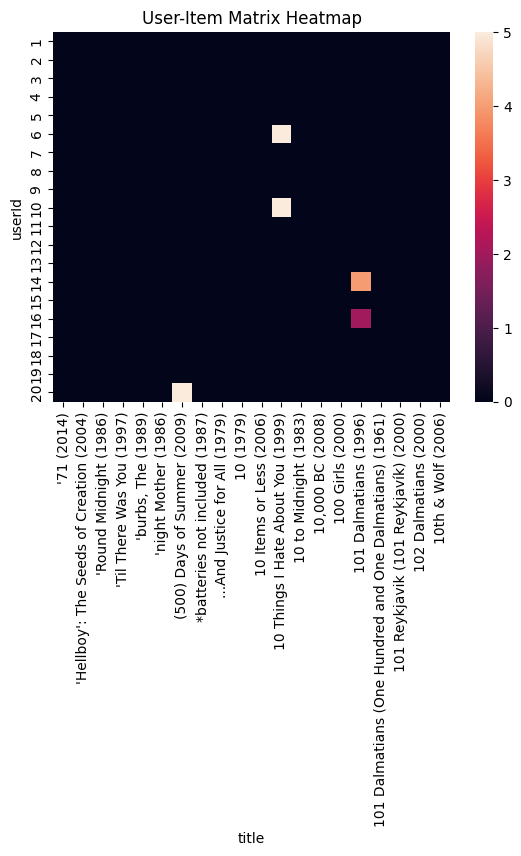

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

Scenario 2


In [ ]:
item_user_matrix = user_item_matrix_filled.T

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

item_similarity = cosine_similarity(item_user_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user_matrix.index,
                                  columns=item_user_matrix.index)

In [ ]:
def get_similar_movies(movie_name, n=5):
    return item_similarity_df[movie_name].sort_values(ascending=False)[1:n+1]

get_similar_movies("Toy Story (1995)")

,Toy Story (1995)
title,
Star Wars: Episode VI - Return of the Jedi (1983),0.629837
Star Wars: Episode IV - A New Hope (1977),0.628777
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),0.586057
Independence Day (a.k.a. ID4) (1996),0.578368
Back to the Future (1985),0.577313


In [ ]:
def item_based_recommend(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id].dropna()
    scores = {}

    for movie in user_ratings.index:
        similar_movies = get_similar_movies(movie)

        for sim_movie in similar_movies.index:
            scores[sim_movie] = scores.get(sim_movie, 0) + similar_movies[sim_movie] * user_ratings[movie]

    return sorted(scores, key=scores.get, reverse=True)[:n]

item_based_recommend(1)

['Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)',
 'Star Wars: Episode V - The Empire Strikes Back (1980)',
 'Fugitive, The (1993)',
 'Pulp Fiction (1994)',
 'Lord of the Rings: The Fellowship of the Ring, The (2001)']

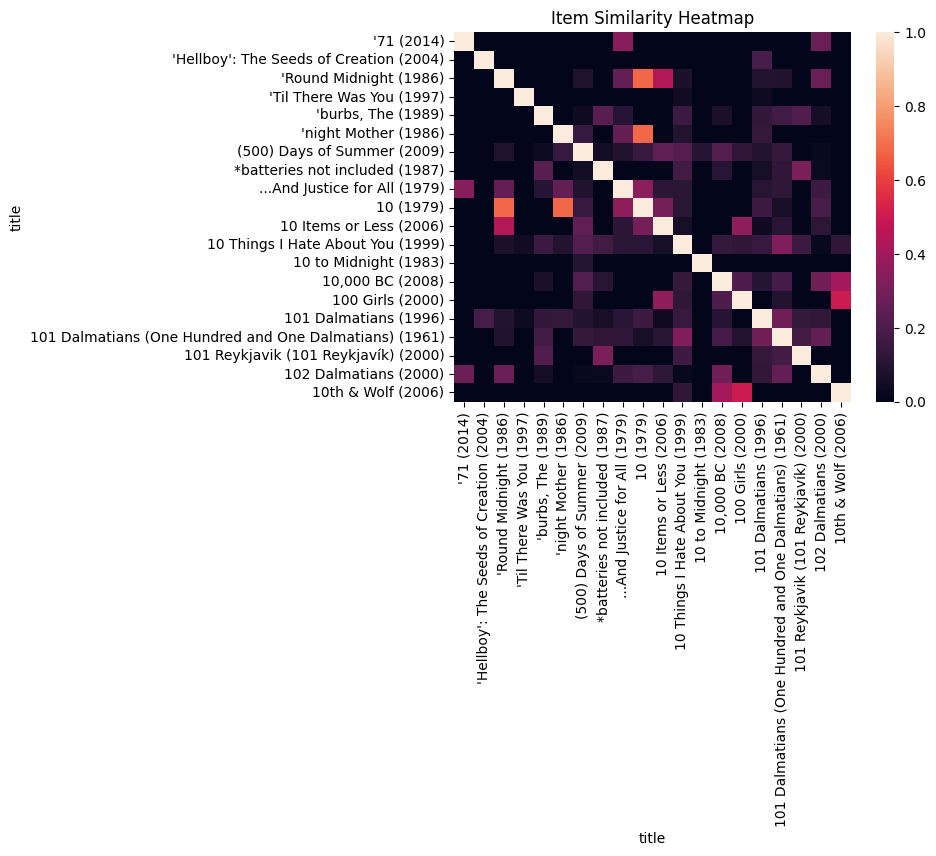

In [ ]:
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()